In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the CSV file and store it in dataframe
df = pd.read_csv('D:/VS Code/Foundations of Data Engineering/Assignment2/input_data.csv')

In [3]:
# Identify feature columns, exclude 'Sl.No'
feature_cols = df.columns.difference(['Sl.No'])

# Calculate mean and standard deviation only for features
mean = df[feature_cols].mean()
std = df[feature_cols].std()

# Calculate the Z Value
z_scores = (df[feature_cols] - mean) / std

# Add back Sl.No Column 
z_scores.insert(0, 'Sl.No', df['Sl.No'])

In [4]:
# Calculate mean and std of normalized data
normalized_mean = z_scores[feature_cols].mean()
normalized_std = z_scores[feature_cols].std()

# Recalculate Z-scores on normalized data and Sl.No Cloumn
z_again = (z_scores[feature_cols] - z_scores[feature_cols].mean()) / z_scores[feature_cols].std()
z_again.insert(0, 'Sl.No', df['Sl.No'])

In [5]:
# Calculate range (max - min) for original, normalized and renormalized data
original_range = np.ptp(df[feature_cols], axis=0)         
normalized_range = np.ptp(z_scores[feature_cols], axis=0) 
renormalized_range = np.ptp(z_again[feature_cols], axis=0)

In [6]:
# Calculate min and max for original data
original_min = df[feature_cols].min()
original_max = df[feature_cols].max()

# Calculate min and max for normalized (z-score) data
normalized_min = z_scores[feature_cols].min()
normalized_max = z_scores[feature_cols].max()

# Calculate min and max for re-normalized data (z_again)
renormalized_min = z_again[feature_cols].min()
renormalized_max = z_again[feature_cols].max()

In [7]:
# Print ranges
print("Original Data Range:")
for feature in feature_cols:
    print(f"{feature}: {original_min[feature]:.2f} to {original_max[feature]:.2f}")

print("\nNormalized Data (Z-score) Range:")
for feature in feature_cols:
    print(f"{feature}: {normalized_min[feature]:.2f} to {normalized_max[feature]:.2f}")

print("\nRe-normalized Data (Z of Z) Range:")
for feature in feature_cols:
    print(f"{feature}: {renormalized_min[feature]:.2f} to {renormalized_max[feature]:.2f}")

Original Data Range:
Age: 20.00 to 25.00
Gender: 0.00 to 1.00
Height: 153.00 to 180.00
Salary: 51000.00 to 300000.00
Weight: 45.00 to 90.00

Normalized Data (Z-score) Range:
Age: -1.52 to 1.41
Gender: -0.94 to 1.02
Height: -1.63 to 1.64
Salary: -0.88 to 2.26
Weight: -1.29 to 1.71

Re-normalized Data (Z of Z) Range:
Age: -1.52 to 1.41
Gender: -0.94 to 1.02
Height: -1.63 to 1.64
Salary: -0.88 to 2.26
Weight: -1.29 to 1.71


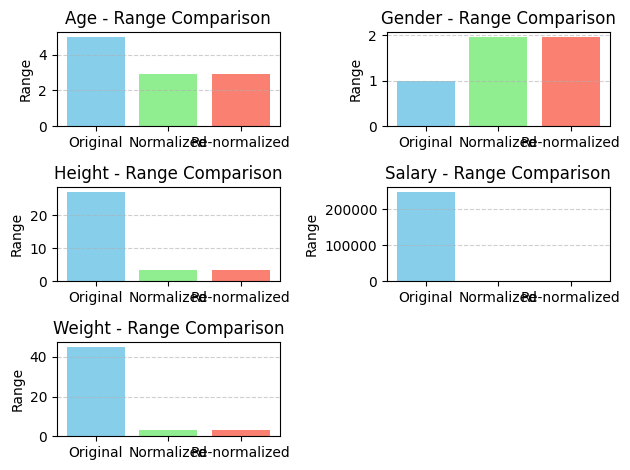

In [8]:
# Plot bar chart comparing range of original vs normalized vs re-normalized
for i, feature in enumerate(feature_cols):
    plt.subplot(3, 2, i + 1)
    
    # Plot side-by-side bars for each feature
    plt.bar(['Original', 'Normalized', 'Re-normalized'],
            [original_range[feature], 
             normalized_range[feature], 
             renormalized_range[feature]],
            color=['skyblue', 'lightgreen', 'salmon'])

    plt.title(f'{feature} - Range Comparison')
    plt.ylabel('Range')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()